## P1 — Load, Clean & Merge

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

deliveries = pd.read_csv('deliveries.csv')
routes = pd.read_csv('routes.csv')

In [14]:
deliveries.head()

,record_id,month,route_id,hub,promised_days,actual_days
0,1,Jan,R1,Ahmedabad,2,2
1,2,Jan,R2,Chennai,3,4
2,3,Jan,R3,Delhi,5,5
3,4,Jan,R4,Mumbai,4,10
4,5,Feb,R1,Chennai,2,5


In [15]:
deliveries.tail()

,record_id,month,route_id,hub,promised_days,actual_days
8,9,Mar,R1,Delhi,2,8
9,10,Mar,R2,Mumbai,3,5
10,11,Mar,R3,Chennai,5,5
11,12,Mar,R4,Mumbai,6,15
12,12,Mar,R4,Mumbai,6,15


In [16]:
routes.head()

,route_id,route_name,service_type
0,R1,Metro Link,Express
1,R2,City Dash,Express
2,R3,Highway Freight,Standard
3,R4,Rural Feeder,Standard


In [17]:
print("------Shape:------")
print(deliveries.shape)

print("-----Missing Values:------")
print(deliveries.isnull().sum())

print("-----Statistical Summary:------")
print(deliveries.describe())

------Shape:------
(13, 6)
-----Missing Values:------
record_id        0
month            0
route_id         0
hub              0
promised_days    0
actual_days      0
dtype: int64
-----Statistical Summary:------
       record_id  promised_days  actual_days
count  13.000000      13.000000    13.000000
mean    6.923077       4.000000     7.230769
std     3.774068       1.581139     4.206222
min     1.000000       2.000000     2.000000
25%     4.000000       3.000000     5.000000
50%     7.000000       4.000000     5.000000
75%    10.000000       5.000000    10.000000
max    12.000000       6.000000    15.000000


In [18]:
print("------Shape:------")
print(routes.shape)

print("-----Missing Values:------")
print(routes.isnull().sum())

print("-----Statistical Summary:------")
print(routes.describe())

------Shape:------
(4, 3)
-----Missing Values:------
route_id        0
route_name      0
service_type    0
dtype: int64
-----Statistical Summary:------
       route_id  route_name service_type
count         4           4            4
unique        4           4            2
top          R1  Metro Link      Express
freq          1           1            2


In [19]:
print("promised_days type:", deliveries['promised_days'].dtype)
print("actual_days type:", deliveries['actual_days'].dtype)

deliveries = deliveries.drop_duplicates()
df = deliveries.merge(routes, on='route_id', how='left')

assert len(df) == 12
assert df['service_type'].isna().sum() == 0

promised_days type: int64
actual_days type: int64


## P2 — Derived Field & Service-Type Analysis

In [20]:
# Calculate delay_days
df['delay_days'] = (df['actual_days'] - df['promised_days']).clip(lower=0)

# Identify delayed records
df['is_delayed'] = df['actual_days'] > df['promised_days']

# Service-type summary
service_summary = (
    df.groupby('service_type')
      .agg(
          total_delay_days=('delay_days', 'sum'),
          delayed_records=('is_delayed', 'sum'),
          total_records=('record_id', 'count'))
      .reset_index())

# Delay incidence rate
service_summary['delay_incidence_rate'] = (
    service_summary['delayed_records']
    / service_summary['total_records']
    * 100
)

# Keep required columns
service_summary = service_summary[
    ['service_type', 'total_delay_days', 'delay_incidence_rate']
]

route_delay = df.groupby('route_id')['delay_days'].sum()      # Route with greatest summed delay_days

highest_route = route_delay.idxmax()
highest_route_delay = route_delay.max()

overall_delay = df['delay_days'].sum()                   # Overall total delay

highest_route_share = (                              # Share of overall total delay
    highest_route_delay / overall_delay * 100
)

In [21]:
print("Route with greatest summed delay_days:", highest_route)
print("Greatest summed delay_days:", round(highest_route_delay, 2))
print("Share of overall total delay_days (%):", round(highest_route_share, 2))

Route with greatest summed delay_days: R4
Greatest summed delay_days: 16
Share of overall total delay_days (%): 48.48


## P3 — Monthly Total Delay Chart

In [22]:
month_order = ['Jan', 'Feb', 'Mar']

df['month'] = pd.Categorical(df['month'],categories=month_order,ordered=True)

monthly_delay = (df.groupby('month', observed=False)['delay_days'].sum().reindex(month_order))

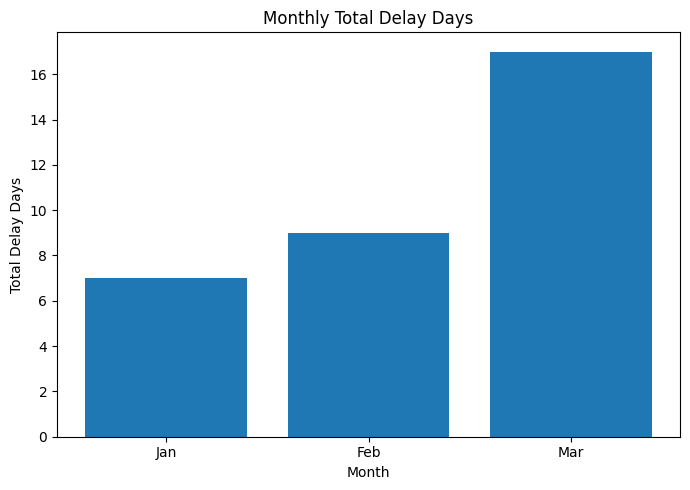

In [23]:
plt.figure(figsize=(7, 5))

plt.bar(monthly_delay.index, monthly_delay.values)

plt.title('Monthly Total Delay Days')
plt.xlabel('Month')
plt.ylabel('Total Delay Days')

plt.tight_layout()
plt.show()
plt.savefig('python_chart.png')
plt.close()

In [24]:
df.to_csv('clean_data.csv', index=False)

service_summary.to_csv('python_summary.csv', index=False)